# 08e — Top ProteinMPNN Lead MD Validation

## Pipeline 4 — Dynamic validation of the top AI-derived peptide leads

This notebook performs explicit-solvent molecular dynamics on the two
ProteinMPNN candidates that survived the `08d` structural filters:

```text
MPNN_NEW_05 = IGPRHQYRDLP
MPNN_NEW_01 = TGPRNQYRDLP
```

`08d` ranked these as the two strongest new ProteinMPNN candidates after
FoldX + Rosetta FlexPepDock refinement.

Established PEARL references:

```text
F0010 = IGERCQYRDLK
CF06  = IGERCQYRELR
CF02  = IGERSQYRELK
```

are **not simulated again** here. Their existing 1 ns MD results from `07d`
are imported for comparison.

---

## Protocol

The production protocol is intentionally aligned with `07d`:

```text
explicit solvent
AMBER ff14SB
TIP3P water
0.15 M NaCl
300 K
1 bar
2 fs timestep

minimization
→ 100 ps NVT
→ 100 ps NPT
→ 1 ns production

500 protein-only production frames
```

For each new candidate we calculate:

```text
peptide Cα RMSD
peptide Cα RMSF
B–D heavy-atom contact persistence (4.5 Å)
number of persistent contacts ≥50%
mean contact persistence
```

---

## Scientific objective

The question is not whether a ProteinMPNN candidate has a good static score.

The question is:

> Does the favorable FoldX/Rosetta structure remain stable dynamically in explicit solvent?

Only after this step can the new ProteinMPNN leads be compared more fairly
with the established CLEAR-derived candidates.
## EXECUTION WITH Python (PEARL MD)

## 1. Environment check

In [1]:
import sys
from pathlib import Path

print("Python:", sys.version)
print("Working directory:", Path.cwd())

try:
    import openmm
    from openmm import app, unit
    print("OpenMM:", openmm.__version__)
except Exception as exc:
    raise RuntimeError(
        "OpenMM is unavailable. Use the Python (PEARL MD) kernel. "
        f"Original error: {exc}"
    )

try:
    import MDAnalysis as mda
    print("MDAnalysis:", mda.__version__)
except Exception as exc:
    raise RuntimeError(
        "MDAnalysis is unavailable in the current kernel. "
        f"Original error: {exc}"
    )

print("Environment check: PASS")


Python: 3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:29:05) [Clang 19.1.7 ]
Working directory: /Users/robertobruzzese/Desktop/venv
OpenMM: 8.5.2
MDAnalysis: 2.10.0
Environment check: PASS


## 2. Imports

In [2]:
import os
import re
import json
import math
import time
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openmm import (
    LangevinMiddleIntegrator,
    MonteCarloBarostat,
)
from openmm.app import (
    PDBFile,
    Modeller,
    ForceField,
    Simulation,
    DCDReporter,
    StateDataReporter,
    NoCutoff,
    PME,
    HBonds,
)

from MDAnalysis.analysis import rms

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 300)

print("Imports OK")


Imports OK


## 3. Configuration

In [3]:
# ======================================================
# TEST / PRODUCTION SWITCH
# ======================================================
# Start with True to validate the complete workflow.
# After QC passes, rerun with False for the final 1 ns run.
FAST_TEST_MODE = True

# ======================================================
# Candidates selected in 08d
# ======================================================
TARGET_CANDIDATES = [
    "MPNN_NEW_05",
    "MPNN_NEW_01",
]

# 08d tables.
STRUCTURAL_RANKING_CSV = (
    Path("outputs")
    / "pipeline_4_ai_08d_structural_validation"
    / "tables"
    / "08d_integrated_structural_ranking.csv"
)

ROSETTA_SUMMARY_CSV = (
    Path("outputs")
    / "pipeline_4_ai_08d_structural_validation"
    / "tables"
    / "08d_Rosetta_summary.csv"
)

ROSETTA_OUTPUT_ROOT = (
    Path("outputs")
    / "pipeline_4_ai_08d_structural_validation"
    / "rosetta"
    / "outputs"
)

# Existing 07d results.
REFERENCE_07D_CANDIDATES = [
    "F0010",
    "CF06",
    "CF02",
]

REFERENCE_07D_SEARCH_ROOT = Path("outputs")

# ======================================================
# Structure definition
# ======================================================
RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

CONTACT_CUTOFF_A = 4.5
PERSISTENCE_THRESHOLD = 0.50

# ======================================================
# MD physical parameters
# ======================================================
TEMPERATURE_K = 300.0
PRESSURE_BAR = 1.0
IONIC_STRENGTH_M = 0.15

TIMESTEP_FS = 2.0
FRICTION_PER_PS = 1.0

NONBONDED_CUTOFF_NM = 1.0
PADDING_NM = 1.0

# ======================================================
# Simulation lengths
# ======================================================
if FAST_TEST_MODE:
    MODE_LABEL = "smoke_test"
    NVT_PS = 10.0
    NPT_PS = 10.0
    PRODUCTION_PS = 50.0
    N_PRODUCTION_FRAMES = 25
else:
    MODE_LABEL = "production_1ns"
    NVT_PS = 100.0
    NPT_PS = 100.0
    PRODUCTION_PS = 1000.0
    N_PRODUCTION_FRAMES = 500

# ======================================================
# Reproducibility
# ======================================================
RANDOM_SEED = 20260810

# ======================================================
# Output
# ======================================================
OUTPUT_ROOT = (
    Path("outputs")
    / "pipeline_4_ai_08e_top_mpnn_md"
    / MODE_LABEL
)

PREP_DIR = OUTPUT_ROOT / "prepared"
TRAJ_DIR = OUTPUT_ROOT / "trajectory"
ANALYSIS_DIR = OUTPUT_ROOT / "analysis"
TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [
    OUTPUT_ROOT,
    PREP_DIR,
    TRAJ_DIR,
    ANALYSIS_DIR,
    TABLE_DIR,
    REPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("FAST_TEST_MODE:", FAST_TEST_MODE)
print("Mode:", MODE_LABEL)
print("Targets:", TARGET_CANDIDATES)
print("NVT:", NVT_PS, "ps")
print("NPT:", NPT_PS, "ps")
print("Production:", PRODUCTION_PS, "ps")
print("Production frames:", N_PRODUCTION_FRAMES)
print("Output:", OUTPUT_ROOT.resolve())


FAST_TEST_MODE: True
Mode: smoke_test
Targets: ['MPNN_NEW_05', 'MPNN_NEW_01']
NVT: 10.0 ps
NPT: 10.0 ps
Production: 50.0 ps
Production frames: 25
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_test


### Important

Run `08e` first with:

```python
FAST_TEST_MODE = True
```

This is only a smoke test.

If both candidates complete and the QC is positive, change **only**:

```python
FAST_TEST_MODE = False
```

and rerun from the beginning for the final 1 ns production trajectories.

This is the only deliberate test/production flag in `08e`.


## 4. Load the 08d ranking and Rosetta summary

In [4]:
if not STRUCTURAL_RANKING_CSV.exists():
    raise FileNotFoundError(
        f"Missing 08d structural ranking: {STRUCTURAL_RANKING_CSV}"
    )

if not ROSETTA_SUMMARY_CSV.exists():
    raise FileNotFoundError(
        f"Missing 08d Rosetta summary: {ROSETTA_SUMMARY_CSV}"
    )

structural_df = pd.read_csv(
    STRUCTURAL_RANKING_CSV
)

rosetta_summary_df = pd.read_csv(
    ROSETTA_SUMMARY_CSV
)

display(
    structural_df[
        structural_df["candidate_id"].isin(
            TARGET_CANDIDATES
        )
    ]
)

display(
    rosetta_summary_df[
        rosetta_summary_df["candidate_id"].isin(
            TARGET_CANDIDATES
        )
    ]
)


,structural_rank,candidate_id,peptide_sequence,AI_integrated_score,ESM2_PLL_mean,best_ProteinMPNN_score,hamming_vs_F0010_recalc,foldx_interaction_energy_kcal_mol,best_total_score,best_I_sc,best_description,FoldX_rank,Rosetta_rank,structural_rank_sum
0,1,MPNN_NEW_05,IGPRHQYRDLP,0.508830,-3.174593,1.4079,3,-13.7478,105.869,-56.118,MPNN_NEW_05_refined_0015,1.0,1.0,2.0
1,2,MPNN_NEW_01,TGPRNQYRDLP,0.601249,-3.172003,1.2473,4,-11.7407,119.107,-54.169,MPNN_NEW_01_refined_0009,3.0,2.0,5.0


,candidate_id,peptide_sequence,best_total_score,best_I_sc,best_description,scorefile
0,MPNN_NEW_05,IGPRHQYRDLP,105.869,-56.118,MPNN_NEW_05_refined_0015,outputs/pipeline_4_ai_08d_structural_validatio...
2,MPNN_NEW_01,TGPRNQYRDLP,119.107,-54.169,MPNN_NEW_01_refined_0009,outputs/pipeline_4_ai_08d_structural_validatio...


## 5. Resolve the best Rosetta decoy PDB for each candidate

In [5]:
def resolve_best_rosetta_pdb(candidate_id, best_description):
    candidate_dir = (
        ROSETTA_OUTPUT_ROOT
        / candidate_id
    )

    if not candidate_dir.exists():
        return None

    desc = str(best_description)

    candidates = [
        candidate_dir / f"{desc}.pdb",
    ]

    for p in candidates:
        if p.exists():
            return p.resolve()

    # Fallback: exact stem search.
    matches = [
        p for p in candidate_dir.glob("*.pdb")
        if p.stem == desc
    ]

    if matches:
        return matches[0].resolve()

    # Fallback: substring search.
    matches = [
        p for p in candidate_dir.glob("*.pdb")
        if desc in p.stem
    ]

    return (
        matches[0].resolve()
        if matches
        else None
    )


input_rows = []

for candidate_id in TARGET_CANDIDATES:

    match = rosetta_summary_df[
        rosetta_summary_df["candidate_id"]
        == candidate_id
    ]

    if match.empty:
        raise RuntimeError(
            f"No Rosetta summary row for {candidate_id}"
        )

    row = match.iloc[0]

    best_description = row[
        "best_description"
    ]

    pdb_path = resolve_best_rosetta_pdb(
        candidate_id,
        best_description,
    )

    input_rows.append({
        "candidate_id": candidate_id,
        "peptide_sequence": row.get(
            "peptide_sequence",
            None,
        ),
        "best_I_sc": row.get(
            "best_I_sc",
            np.nan,
        ),
        "best_description": best_description,
        "input_pdb": (
            str(pdb_path)
            if pdb_path is not None
            else None
        ),
        "input_present": (
            pdb_path is not None
        ),
    })

input_df = pd.DataFrame(
    input_rows
)

display(input_df)

if not input_df[
    "input_present"
].all():
    raise FileNotFoundError(
        "One or more best Rosetta decoy PDBs could not be located."
    )

input_df.to_csv(
    TABLE_DIR / "08e_input_structures.csv",
    index=False,
)


,candidate_id,peptide_sequence,best_I_sc,best_description,input_pdb,input_present
0,MPNN_NEW_05,IGPRHQYRDLP,-56.118,MPNN_NEW_05_refined_0015,/Users/robertobruzzese/Desktop/venv/outputs/pi...,True
1,MPNN_NEW_01,TGPRNQYRDLP,-54.169,MPNN_NEW_01_refined_0009,/Users/robertobruzzese/Desktop/venv/outputs/pi...,True


## 6. Inspect chains and peptide sequences

In [6]:
THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

def pdb_chain_sequence(
    pdb_path,
    chain_id,
):
    sequence = []
    seen = set()

    with open(
        pdb_path,
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as handle:

        for line in handle:
            if not line.startswith("ATOM"):
                continue

            chain = line[21].strip()

            if chain != chain_id:
                continue

            resname = line[17:20].strip()
            resid = (
                line[22:26].strip(),
                line[26].strip(),
            )

            if resid in seen:
                continue

            seen.add(resid)

            if resname in THREE_TO_ONE:
                sequence.append(
                    THREE_TO_ONE[resname]
                )

    return "".join(sequence)


structure_qc_rows = []

for _, row in input_df.iterrows():

    pdb_path = Path(
        row["input_pdb"]
    )

    receptor_seq = pdb_chain_sequence(
        pdb_path,
        RECEPTOR_CHAIN,
    )

    peptide_seq = pdb_chain_sequence(
        pdb_path,
        PEPTIDE_CHAIN,
    )

    structure_qc_rows.append({
        "candidate_id": row["candidate_id"],
        "expected_peptide_sequence": row["peptide_sequence"],
        "observed_peptide_sequence": peptide_seq,
        "receptor_length": len(receptor_seq),
        "peptide_length": len(peptide_seq),
        "peptide_sequence_match": (
            peptide_seq
            == row["peptide_sequence"]
        ),
    })

structure_qc_df = pd.DataFrame(
    structure_qc_rows
)

display(structure_qc_df)

if not structure_qc_df[
    "peptide_sequence_match"
].all():
    raise RuntimeError(
        "A Rosetta best-pose peptide sequence does not match the expected 08d sequence."
    )


,candidate_id,expected_peptide_sequence,observed_peptide_sequence,receptor_length,peptide_length,peptide_sequence_match
0,MPNN_NEW_05,IGPRHQYRDLP,IGPRHQYRDLP,614,11,True
1,MPNN_NEW_01,TGPRNQYRDLP,TGPRNQYRDLP,614,11,True


## 7. Utility: keep only receptor B + peptide D

Rosetta/FoldX structures may contain additional records.

For MD we explicitly retain only chains B and D before solvation.


In [7]:
def write_selected_chains(
    input_pdb,
    output_pdb,
    keep_chains=("B", "D"),
):
    keep = set(
        keep_chains
    )

    output_lines = []

    with open(
        input_pdb,
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as handle:

        for line in handle:

            if line.startswith(
                ("ATOM", "HETATM", "TER")
            ):
                chain = (
                    line[21].strip()
                    if len(line) > 21
                    else ""
                )

                if (
                    line.startswith("TER")
                    or chain in keep
                ):
                    output_lines.append(
                        line
                    )

            elif line.startswith("END"):
                continue

    output_lines.append(
        "END\n"
    )

    Path(output_pdb).write_text(
        "".join(output_lines),
        encoding="utf-8",
    )


## 8. Prepare chain-B/D starting structures

In [8]:
prepared_input_rows = []

for _, row in input_df.iterrows():

    candidate_id = row[
        "candidate_id"
    ]

    src = Path(
        row["input_pdb"]
    )

    dst = (
        PREP_DIR
        / f"{candidate_id}_BD_input.pdb"
    )

    write_selected_chains(
        src,
        dst,
        keep_chains=(
            RECEPTOR_CHAIN,
            PEPTIDE_CHAIN,
        ),
    )

    prepared_input_rows.append({
        "candidate_id": candidate_id,
        "peptide_sequence": row[
            "peptide_sequence"
        ],
        "prepared_input_pdb": str(
            dst
        ),
    })

prepared_input_df = pd.DataFrame(
    prepared_input_rows
)

display(prepared_input_df)


,candidate_id,peptide_sequence,prepared_input_pdb
0,MPNN_NEW_05,IGPRHQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...
1,MPNN_NEW_01,TGPRNQYRDLP,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...


## 9. Force field

We use the same PEARL MD force-field family:

```text
AMBER ff14SB + TIP3P
```

The notebook first tries `amber14/protein.ff14SB.xml` and `amber14/tip3p.xml`.


In [9]:
FORCEFIELD_CANDIDATES = [
    (
        "amber14/protein.ff14SB.xml",
        "amber14/tip3p.xml",
    ),
    (
        "amber14-all.xml",
        "amber14/tip3p.xml",
    ),
]

forcefield = None
forcefield_names = None

last_exc = None

for ff_names in FORCEFIELD_CANDIDATES:
    try:
        forcefield = ForceField(
            *ff_names
        )
        forcefield_names = ff_names
        break
    except Exception as exc:
        last_exc = exc

if forcefield is None:
    raise RuntimeError(
        "Could not load the intended AMBER/TIP3P force field. "
        f"Last error: {last_exc}"
    )

print(
    "Force field:",
    forcefield_names,
)


Force field: ('amber14/protein.ff14SB.xml', 'amber14/tip3p.xml')


## 10. Platform selection

In [13]:
available_platforms = [
    openmm.Platform.getPlatform(i).getName()
    for i in range(
        openmm.Platform.getNumPlatforms()
    )
]

print(
    "Available OpenMM platforms:",
    available_platforms,
)

# ------------------------------------------------------
# PEARL 08e platform choice
#
# On this Mac, the OpenCL plugin may be registered
# even when no compatible OpenCL device can actually
# create an OpenMM Context.
#
# For reliability we use CPU here.
# ------------------------------------------------------

if "CPU" not in available_platforms:
    raise RuntimeError(
        "OpenMM CPU platform is not available."
    )

PLATFORM = (
    openmm.Platform.getPlatformByName(
        "CPU"
    )
)

PLATFORM_PROPERTIES = {}

print(
    "Selected platform:",
    PLATFORM.getName(),
)

print(
    "Platform properties:",
    PLATFORM_PROPERTIES,
)


Available OpenMM platforms: ['Reference', 'CPU', 'OpenCL']
Selected platform: CPU
Platform properties: {}


## 11. MD runner

In [14]:
def ps_to_steps(
    time_ps,
    timestep_fs=2.0,
):
    return int(
        round(
            time_ps
            * 1000.0
            / timestep_fs
        )
    )


def run_candidate_md(
    candidate_id,
    input_pdb,
):
    candidate_root = (
        OUTPUT_ROOT
        / candidate_id
    )

    candidate_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    candidate_traj_dir = (
        candidate_root
        / "trajectory"
    )

    candidate_traj_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    candidate_log_dir = (
        candidate_root
        / "logs"
    )

    candidate_log_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # ----------------------------------------------
    # Load
    # ----------------------------------------------
    pdb = PDBFile(
        str(input_pdb)
    )

    modeller = Modeller(
        pdb.topology,
        pdb.positions,
    )

    # ----------------------------------------------
    # Add hydrogens
    # ----------------------------------------------
    modeller.addHydrogens(
        forcefield,
        pH=7.4,
    )

    # ----------------------------------------------
    # Solvate
    # ----------------------------------------------
    modeller.addSolvent(
        forcefield,
        model="tip3p",
        padding=PADDING_NM * unit.nanometer,
        ionicStrength=(
            IONIC_STRENGTH_M
            * unit.molar
        ),
        neutralize=True,
    )

    solvated_pdb = (
        candidate_root
        / f"{candidate_id}_solvated.pdb"
    )

    with open(
        solvated_pdb,
        "w",
    ) as handle:
        PDBFile.writeFile(
            modeller.topology,
            modeller.positions,
            handle,
            keepIds=True,
        )

    # ----------------------------------------------
    # System
    # ----------------------------------------------
    system = forcefield.createSystem(
        modeller.topology,
        nonbondedMethod=PME,
        nonbondedCutoff=(
            NONBONDED_CUTOFF_NM
            * unit.nanometer
        ),
        constraints=HBonds,
        rigidWater=True,
    )

    # NVT first. Barostat added only before NPT.
    integrator = LangevinMiddleIntegrator(
        TEMPERATURE_K * unit.kelvin,
        FRICTION_PER_PS / unit.picosecond,
        TIMESTEP_FS * unit.femtoseconds,
    )

    integrator.setRandomNumberSeed(
        RANDOM_SEED
    )

    simulation = Simulation(
        modeller.topology,
        system,
        integrator,
        PLATFORM,
        PLATFORM_PROPERTIES,
    )

    simulation.context.setPositions(
        modeller.positions
    )

    # ----------------------------------------------
    # Minimization
    # ----------------------------------------------
    print(
        f"[{candidate_id}] Minimization..."
    )

    simulation.minimizeEnergy(
        maxIterations=1000
    )

    minimized_pdb = (
        candidate_root
        / f"{candidate_id}_minimized.pdb"
    )

    min_state = simulation.context.getState(
        getPositions=True,
        getEnergy=True,
    )

    with open(
        minimized_pdb,
        "w",
    ) as handle:
        PDBFile.writeFile(
            simulation.topology,
            min_state.getPositions(),
            handle,
            keepIds=True,
        )

    # ----------------------------------------------
    # Velocities
    # ----------------------------------------------
    simulation.context.setVelocitiesToTemperature(
        TEMPERATURE_K * unit.kelvin,
        RANDOM_SEED,
    )

    # ----------------------------------------------
    # NVT
    # ----------------------------------------------
    nvt_steps = ps_to_steps(
        NVT_PS,
        TIMESTEP_FS,
    )

    nvt_log = (
        candidate_log_dir
        / "nvt.csv"
    )

    simulation.reporters.append(
        StateDataReporter(
            str(nvt_log),
            max(
                1,
                nvt_steps // 20,
            ),
            step=True,
            time=True,
            temperature=True,
            potentialEnergy=True,
            kineticEnergy=True,
            totalEnergy=True,
            separator=",",
        )
    )

    print(
        f"[{candidate_id}] NVT {NVT_PS} ps..."
    )

    simulation.step(
        nvt_steps
    )

    simulation.reporters.clear()

    # ----------------------------------------------
    # NPT
    # ----------------------------------------------
    system.addForce(
        MonteCarloBarostat(
            PRESSURE_BAR * unit.bar,
            TEMPERATURE_K * unit.kelvin,
            25,
        )
    )

    # Reinitialize context preserving state after adding barostat.
    simulation.context.reinitialize(
        preserveState=True
    )

    npt_steps = ps_to_steps(
        NPT_PS,
        TIMESTEP_FS,
    )

    npt_log = (
        candidate_log_dir
        / "npt.csv"
    )

    simulation.reporters.append(
        StateDataReporter(
            str(npt_log),
            max(
                1,
                npt_steps // 20,
            ),
            step=True,
            time=True,
            temperature=True,
            density=True,
            potentialEnergy=True,
            totalEnergy=True,
            separator=",",
        )
    )

    print(
        f"[{candidate_id}] NPT {NPT_PS} ps..."
    )

    simulation.step(
        npt_steps
    )

    simulation.reporters.clear()

    # ----------------------------------------------
    # Write protein-only topology from equilibrated state
    # ----------------------------------------------
    eq_state = simulation.context.getState(
        getPositions=True,
    )

    all_positions = eq_state.getPositions()

    protein_atom_indices = [
        atom.index
        for atom in simulation.topology.atoms()
        if atom.residue.name not in {
            "HOH",
            "WAT",
            "Na+",
            "Cl-",
            "NA",
            "CL",
        }
    ]

    # Create modeller containing only protein chains B/D.
    protein_modeller = Modeller(
        simulation.topology,
        all_positions,
    )

    delete_atoms = [
        atom
        for atom in protein_modeller.topology.atoms()
        if atom.index not in set(
            protein_atom_indices
        )
    ]

    protein_modeller.delete(
        delete_atoms
    )

    protein_topology_pdb = (
        candidate_traj_dir
        / f"{candidate_id}_protein_topology.pdb"
    )

    with open(
        protein_topology_pdb,
        "w",
    ) as handle:
        PDBFile.writeFile(
            protein_modeller.topology,
            protein_modeller.positions,
            handle,
            keepIds=True,
        )

    # ----------------------------------------------
    # Production
    # ----------------------------------------------
    production_steps = ps_to_steps(
        PRODUCTION_PS,
        TIMESTEP_FS,
    )

    report_interval = max(
        1,
        production_steps
        // N_PRODUCTION_FRAMES
    )

    full_dcd = (
        candidate_traj_dir
        / f"{candidate_id}_production_full.dcd"
    )

    production_log = (
        candidate_log_dir
        / "production.csv"
    )

    simulation.reporters.append(
        DCDReporter(
            str(full_dcd),
            report_interval,
            enforcePeriodicBox=True,
        )
    )

    simulation.reporters.append(
        StateDataReporter(
            str(production_log),
            report_interval,
            step=True,
            time=True,
            temperature=True,
            density=True,
            potentialEnergy=True,
            totalEnergy=True,
            speed=True,
            separator=",",
        )
    )

    print(
        f"[{candidate_id}] Production {PRODUCTION_PS} ps "
        f"({N_PRODUCTION_FRAMES} target frames)..."
    )

    t0 = time.time()

    simulation.step(
        production_steps
    )

    runtime_s = (
        time.time()
        - t0
    )

    simulation.reporters.clear()

    # ----------------------------------------------
    # Convert full DCD to protein-only DCD with MDAnalysis.
    # This keeps the analysis compact and aligned with 07d.
    # ----------------------------------------------
    u = mda.Universe(
        str(solvated_pdb),
        str(full_dcd),
    )

    protein = u.select_atoms(
        f"protein and (segid {RECEPTOR_CHAIN} or segid {PEPTIDE_CHAIN})"
    )

    # PDB readers sometimes expose chain IDs instead of segids.
    if protein.n_atoms == 0:
        protein = u.select_atoms(
            f"protein and (chainID {RECEPTOR_CHAIN} or chainID {PEPTIDE_CHAIN})"
        )

    if protein.n_atoms == 0:
        protein = u.select_atoms(
            "protein"
        )

    protein_dcd = (
        candidate_traj_dir
        / f"{candidate_id}_production_protein.dcd"
    )

    with mda.Writer(
        str(protein_dcd),
        protein.n_atoms,
    ) as writer:
        for ts in u.trajectory:
            writer.write(
                protein
            )

    # Write matching MDAnalysis protein topology.
    mda_protein_pdb = (
        candidate_traj_dir
        / f"{candidate_id}_protein_MDA_topology.pdb"
    )

    protein.write(
        str(mda_protein_pdb)
    )

    metadata = {
        "candidate_id": candidate_id,
        "mode": MODE_LABEL,
        "nvt_ps": NVT_PS,
        "npt_ps": NPT_PS,
        "production_ps": PRODUCTION_PS,
        "target_frames": N_PRODUCTION_FRAMES,
        "report_interval_steps": report_interval,
        "runtime_seconds_production": runtime_s,
        "platform": PLATFORM.getName(),
        "forcefield": forcefield_names,
        "solvated_pdb": str(solvated_pdb),
        "full_dcd": str(full_dcd),
        "protein_dcd": str(protein_dcd),
        "protein_topology_pdb": str(mda_protein_pdb),
        "production_log": str(production_log),
    }

    metadata_path = (
        candidate_root
        / "run_metadata.json"
    )

    metadata_path.write_text(
        json.dumps(
            metadata,
            indent=2,
        ),
        encoding="utf-8",
    )

    print(
        f"[{candidate_id}] production runtime: "
        f"{runtime_s/60:.1f} min"
    )

    return metadata


## 12. Run MD

In smoke-test mode this should be relatively short.

In production mode, each 1 ns explicit-solvent system may take around the same
order of time as the previous `07d` candidate runs on the same machine.


In [15]:
run_metadata = []

for _, row in prepared_input_df.iterrows():

    candidate_id = row[
        "candidate_id"
    ]

    print()
    print("=" * 70)
    print(candidate_id)
    print("=" * 70)

    metadata = run_candidate_md(
        candidate_id,
        Path(
            row[
                "prepared_input_pdb"
            ]
        ),
    )

    run_metadata.append(
        metadata
    )

run_metadata_df = pd.DataFrame(
    run_metadata
)

display(run_metadata_df)

run_metadata_df.to_csv(
    TABLE_DIR
    / "08e_run_metadata.csv",
    index=False,
)



MPNN_NEW_05
[MPNN_NEW_05] Minimization...
[MPNN_NEW_05] NVT 10.0 ps...
[MPNN_NEW_05] NPT 10.0 ps...
[MPNN_NEW_05] Production 50.0 ps (25 target frames)...
[MPNN_NEW_05] production runtime: 35.2 min

MPNN_NEW_01
[MPNN_NEW_01] Minimization...
[MPNN_NEW_01] NVT 10.0 ps...
[MPNN_NEW_01] NPT 10.0 ps...
[MPNN_NEW_01] Production 50.0 ps (25 target frames)...
[MPNN_NEW_01] production runtime: 34.9 min


,candidate_id,mode,nvt_ps,npt_ps,production_ps,target_frames,report_interval_steps,runtime_seconds_production,platform,forcefield,solvated_pdb,full_dcd,protein_dcd,protein_topology_pdb,production_log
0,MPNN_NEW_05,smoke_test,10.0,10.0,50.0,25,1000,2113.325221,CPU,"(amber14/protein.ff14SB.xml, amber14/tip3p.xml)",outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...
1,MPNN_NEW_01,smoke_test,10.0,10.0,50.0,25,1000,2093.267135,CPU,"(amber14/protein.ff14SB.xml, amber14/tip3p.xml)",outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...,outputs/pipeline_4_ai_08e_top_mpnn_md/smoke_te...


## 13. Thermodynamic QC

In [16]:
thermo_rows = []

for metadata in run_metadata:

    candidate_id = metadata[
        "candidate_id"
    ]

    log_path = Path(
        metadata[
            "production_log"
        ]
    )

    df = pd.read_csv(
        log_path
    )

    # Normalize OpenMM StateDataReporter names.
    temp_col = next(
        (
            c for c in df.columns
            if "Temperature" in c
        ),
        None,
    )

    density_col = next(
        (
            c for c in df.columns
            if "Density" in c
        ),
        None,
    )

    row = {
        "candidate_id": candidate_id,
        "n_log_rows": len(df),
        "mean_temperature_K": (
            float(
                df[temp_col].mean()
            )
            if temp_col
            else np.nan
        ),
        "sd_temperature_K": (
            float(
                df[temp_col].std()
            )
            if temp_col
            else np.nan
        ),
        "mean_density_g_ml": (
            float(
                df[density_col].mean()
            )
            if density_col
            else np.nan
        ),
        "sd_density_g_ml": (
            float(
                df[density_col].std()
            )
            if density_col
            else np.nan
        ),
    }

    thermo_rows.append(
        row
    )

thermo_qc_df = pd.DataFrame(
    thermo_rows
)

thermo_qc_df[
    "temperature_QC"
] = (
    thermo_qc_df[
        "mean_temperature_K"
    ].between(
        290,
        310,
    )
)

thermo_qc_df[
    "density_QC"
] = (
    thermo_qc_df[
        "mean_density_g_ml"
    ].between(
        0.95,
        1.05,
    )
)

display(thermo_qc_df)

thermo_qc_df.to_csv(
    TABLE_DIR
    / "08e_thermodynamic_QC.csv",
    index=False,
)


,candidate_id,n_log_rows,mean_temperature_K,sd_temperature_K,mean_density_g_ml,sd_density_g_ml,temperature_QC,density_QC
0,MPNN_NEW_05,25,300.396813,0.776906,1.001349,0.000960,True,True
1,MPNN_NEW_01,25,300.093334,0.586016,1.001659,0.000922,True,True


## 14. Load production protein trajectories

In [17]:
universes = {}

trajectory_qc_rows = []

for metadata in run_metadata:

    candidate_id = metadata[
        "candidate_id"
    ]

    topology = Path(
        metadata[
            "protein_topology_pdb"
        ]
    )

    dcd = Path(
        metadata[
            "protein_dcd"
        ]
    )

    u = mda.Universe(
        str(topology),
        str(dcd),
    )

    universes[
        candidate_id
    ] = u

    trajectory_qc_rows.append({
        "candidate_id": candidate_id,
        "n_atoms": u.atoms.n_atoms,
        "n_frames": len(
            u.trajectory
        ),
    })

trajectory_qc_df = pd.DataFrame(
    trajectory_qc_rows
)

display(trajectory_qc_df)


,candidate_id,n_atoms,n_frames
0,MPNN_NEW_05,9477,25
1,MPNN_NEW_01,9469,25


## 15. Chain-selection helper

In [18]:
def select_chain(
    universe,
    chain_id,
    extra_selection="",
):
    selections = [
        f"chainID {chain_id}",
        f"segid {chain_id}",
    ]

    for base in selections:

        sel = (
            f"({base}) and ({extra_selection})"
            if extra_selection
            else base
        )

        atoms = universe.select_atoms(
            sel
        )

        if atoms.n_atoms > 0:
            return atoms

    raise RuntimeError(
        f"Could not select chain {chain_id}"
    )


## 16. Peptide Cα RMSD

In [20]:
from MDAnalysis.analysis import align
rmsd_rows = []
rmsd_series = {}

for candidate_id, u in universes.items():

    receptor_ca = select_chain(
        u,
        RECEPTOR_CHAIN,
        "protein and name CA",
    )

    peptide_ca = select_chain(
        u,
        PEPTIDE_CHAIN,
        "protein and name CA",
    )

    if peptide_ca.n_atoms == 0:
        raise RuntimeError(
            f"No peptide C-alpha atoms for {candidate_id}"
        )

    # Align using receptor Cα atoms so peptide RMSD describes
    # motion relative to the receptor.
    ref_receptor = (
        receptor_ca.positions.copy()
    )

    ref_peptide = (
        peptide_ca.positions.copy()
    )

    values = []

    for frame_idx, ts in enumerate(
        u.trajectory
    ):

        # Kabsch align receptor current -> receptor reference.
        mobile = (
            receptor_ca.positions
            - receptor_ca.positions.mean(
                axis=0
            )
        )

        reference = (
            ref_receptor
            - ref_receptor.mean(
                axis=0
            )
        )

        R, _ = mda.analysis.align.rotation_matrix(
            mobile,
            reference,
        )

        current_receptor_center = (
            receptor_ca.positions.mean(
                axis=0
            )
        )

        ref_center = (
            ref_receptor.mean(
                axis=0
            )
        )

        peptide_aligned = (
            peptide_ca.positions
            - current_receptor_center
        ) @ R.T + ref_center

        diff = (
            peptide_aligned
            - ref_peptide
        )

        rmsd_a = float(
            np.sqrt(
                np.mean(
                    np.sum(
                        diff * diff,
                        axis=1,
                    )
                )
            )
        )

        values.append(
            rmsd_a
        )

        rmsd_rows.append({
            "candidate_id": candidate_id,
            "frame": frame_idx,
            "peptide_CA_RMSD_A": rmsd_a,
        })

    rmsd_series[
        candidate_id
    ] = np.array(
        values
    )

rmsd_df = pd.DataFrame(
    rmsd_rows
)

rmsd_df.to_csv(
    TABLE_DIR
    / "08e_peptide_CA_RMSD_timeseries.csv",
    index=False,
)

display(
    rmsd_df.groupby(
        "candidate_id"
    )[
        "peptide_CA_RMSD_A"
    ].agg(
        ["mean", "std", "min", "max"]
    )
)


,mean,std,min,max
candidate_id,,,,
MPNN_NEW_01,0.676206,0.192056,0.0,0.98033
MPNN_NEW_05,0.733550,0.208898,0.0,1.04395


## 17. Peptide Cα RMSF

In [21]:
rmsf_rows = []
rmsf_summary_rows = []

for candidate_id, u in universes.items():

    receptor_ca = select_chain(
        u,
        RECEPTOR_CHAIN,
        "protein and name CA",
    )

    peptide_ca = select_chain(
        u,
        PEPTIDE_CHAIN,
        "protein and name CA",
    )

    ref_receptor = (
        receptor_ca.positions.copy()
    )

    aligned_peptide_frames = []

    for ts in u.trajectory:

        mobile = (
            receptor_ca.positions
            - receptor_ca.positions.mean(
                axis=0
            )
        )

        reference = (
            ref_receptor
            - ref_receptor.mean(
                axis=0
            )
        )

        R, _ = mda.analysis.align.rotation_matrix(
            mobile,
            reference,
        )

        current_center = (
            receptor_ca.positions.mean(
                axis=0
            )
        )

        ref_center = (
            ref_receptor.mean(
                axis=0
            )
        )

        peptide_aligned = (
            peptide_ca.positions
            - current_center
        ) @ R.T + ref_center

        aligned_peptide_frames.append(
            peptide_aligned.copy()
        )

    xyz = np.stack(
        aligned_peptide_frames,
        axis=0,
    )

    mean_xyz = xyz.mean(
        axis=0
    )

    rmsf = np.sqrt(
        np.mean(
            np.sum(
                (
                    xyz
                    - mean_xyz[None, :, :]
                ) ** 2,
                axis=2,
            ),
            axis=0,
        )
    )

    for atom, value in zip(
        peptide_ca,
        rmsf,
    ):
        rmsf_rows.append({
            "candidate_id": candidate_id,
            "resid": int(atom.resid),
            "resname": atom.resname,
            "CA_RMSF_A": float(value),
        })

    rmsf_summary_rows.append({
        "candidate_id": candidate_id,
        "mean_peptide_CA_RMSF_A": float(
            np.mean(rmsf)
        ),
        "max_peptide_CA_RMSF_A": float(
            np.max(rmsf)
        ),
    })

rmsf_df = pd.DataFrame(
    rmsf_rows
)

rmsf_summary_df = pd.DataFrame(
    rmsf_summary_rows
)

rmsf_df.to_csv(
    TABLE_DIR
    / "08e_peptide_CA_RMSF_per_residue.csv",
    index=False,
)

display(rmsf_summary_df)


,candidate_id,mean_peptide_CA_RMSF_A,max_peptide_CA_RMSF_A
0,MPNN_NEW_05,0.538316,0.678126
1,MPNN_NEW_01,0.514820,0.616902


## 18. Heavy-atom B–D contact persistence

In [22]:
from MDAnalysis.lib.distances import distance_array

contact_rows = []
contact_summary_rows = []

for candidate_id, u in universes.items():

    receptor_heavy = select_chain(
        u,
        RECEPTOR_CHAIN,
        "protein and not name H*",
    )

    peptide_heavy = select_chain(
        u,
        PEPTIDE_CHAIN,
        "protein and not name H*",
    )

    pair_counts = {}
    n_frames = len(
        u.trajectory
    )

    for ts in u.trajectory:

        distances = distance_array(
            receptor_heavy.positions,
            peptide_heavy.positions,
            box=ts.dimensions,
        )

        atom_pairs = np.argwhere(
            distances
            <= CONTACT_CUTOFF_A
        )

        frame_residue_pairs = set()

        for i, j in atom_pairs:

            ra = receptor_heavy[
                int(i)
            ].residue

            rb = peptide_heavy[
                int(j)
            ].residue

            pair = (
                int(ra.resid),
                ra.resname,
                int(rb.resid),
                rb.resname,
            )

            frame_residue_pairs.add(
                pair
            )

        for pair in frame_residue_pairs:
            pair_counts[pair] = (
                pair_counts.get(
                    pair,
                    0,
                )
                + 1
            )

    candidate_persistences = []

    for (
        receptor_resid,
        receptor_resname,
        peptide_resid,
        peptide_resname,
    ), count in pair_counts.items():

        persistence = (
            count
            / n_frames
        )

        candidate_persistences.append(
            persistence
        )

        contact_rows.append({
            "candidate_id": candidate_id,
            "receptor_resid": receptor_resid,
            "receptor_resname": receptor_resname,
            "peptide_resid": peptide_resid,
            "peptide_resname": peptide_resname,
            "frames_in_contact": count,
            "n_frames": n_frames,
            "persistence": persistence,
            "persistent_ge_50pct": (
                persistence
                >= PERSISTENCE_THRESHOLD
            ),
        })

    persistent = [
        p
        for p in candidate_persistences
        if p >= PERSISTENCE_THRESHOLD
    ]

    contact_summary_rows.append({
        "candidate_id": candidate_id,
        "n_unique_contacts": len(
            candidate_persistences
        ),
        "n_persistent_contacts_50pct": len(
            persistent
        ),
        "mean_contact_persistence": (
            float(
                np.mean(
                    candidate_persistences
                )
            )
            if candidate_persistences
            else np.nan
        ),
        "mean_persistent_contact_persistence": (
            float(
                np.mean(
                    persistent
                )
            )
            if persistent
            else np.nan
        ),
    })

contact_df = pd.DataFrame(
    contact_rows
)

contact_summary_df = pd.DataFrame(
    contact_summary_rows
)

contact_df.to_csv(
    TABLE_DIR
    / "08e_BD_contact_persistence.csv",
    index=False,
)

contact_summary_df.to_csv(
    TABLE_DIR
    / "08e_contact_summary.csv",
    index=False,
)

display(
    contact_summary_df
)


,candidate_id,n_unique_contacts,n_persistent_contacts_50pct,mean_contact_persistence,mean_persistent_contact_persistence
0,MPNN_NEW_05,64,48,0.706875,0.901667
1,MPNN_NEW_01,57,44,0.757193,0.934545


## 19. New-candidate MD summary

In [23]:
rmsd_summary_df = (
    rmsd_df.groupby(
        "candidate_id",
        as_index=False,
    )[
        "peptide_CA_RMSD_A"
    ]
    .agg(
        mean_peptide_CA_RMSD_A="mean",
        sd_peptide_CA_RMSD_A="std",
    )
)

new_md_summary_df = (
    rmsd_summary_df
    .merge(
        rmsf_summary_df,
        on="candidate_id",
        how="left",
    )
    .merge(
        contact_summary_df,
        on="candidate_id",
        how="left",
    )
    .merge(
        thermo_qc_df[
            [
                "candidate_id",
                "mean_temperature_K",
                "mean_density_g_ml",
                "temperature_QC",
                "density_QC",
            ]
        ],
        on="candidate_id",
        how="left",
    )
)

new_md_summary_df.to_csv(
    TABLE_DIR
    / "08e_new_candidate_MD_summary.csv",
    index=False,
)

display(
    new_md_summary_df.sort_values(
        "mean_peptide_CA_RMSD_A",
        ascending=True,
    )
)


,candidate_id,mean_peptide_CA_RMSD_A,sd_peptide_CA_RMSD_A,mean_peptide_CA_RMSF_A,max_peptide_CA_RMSF_A,n_unique_contacts,n_persistent_contacts_50pct,mean_contact_persistence,mean_persistent_contact_persistence,mean_temperature_K,mean_density_g_ml,temperature_QC,density_QC
0,MPNN_NEW_01,0.676206,0.192056,0.514820,0.616902,57,44,0.757193,0.934545,300.093334,1.001659,True,True
1,MPNN_NEW_05,0.733550,0.208898,0.538316,0.678126,64,48,0.706875,0.901667,300.396813,1.001349,True,True


## 20. Locate previous 07d production summary

The exact filename may differ between notebook revisions, so the notebook
searches for likely `07d` CSVs containing F0010, CF06 and CF02 metrics.


In [33]:
REFERENCE_07D_SUMMARY = (
    Path("outputs")
    / "pipeline_3_md_07d_selected_peptide_comparison"
    / "production_1ns"
    / "07d_selected_peptide_MD_comparison.csv"
)

if not REFERENCE_07D_SUMMARY.exists():
    raise FileNotFoundError(
        f"07d summary not found: {REFERENCE_07D_SUMMARY}"
    )

reference_md_df = pd.read_csv(
    REFERENCE_07D_SUMMARY
)

print(
    "Using 07d reference:",
    REFERENCE_07D_SUMMARY
)

display(
    reference_md_df
)


Using 07d reference: outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns/07d_selected_peptide_MD_comparison.csv


,candidate,n_frames,mean_B_CA_RMSD_A,mean_D_CA_RMSD_A,mean_complex_CA_RMSD_A,mean_D_CA_RMSF_A,n_unique_contacts,n_persistent_contacts_50pct,mean_contact_persistence,mean_temperature_K,mean_density_g_mL,QC_PASS,sequence
0,F0010,500,1.914133,1.965916,1.915782,1.163706,81,43,0.540519,300.263891,1.001927,True,IGERCQYRDLK
1,CF06,500,2.467241,1.293427,2.451879,0.903728,88,45,0.528545,300.236596,1.001783,True,IGERCQYRELR
2,CF02,500,1.676600,0.901385,1.666413,0.737052,70,43,0.602886,300.314283,1.002017,True,IGERSQYRELK


## 21. Import established 07d MD metrics

In [34]:
required_reference_candidates = {
    "F0010",
    "CF06",
    "CF02",
}

candidate_col = next(
    (
        c for c in [
            "candidate",
            "candidate_id",
            "name",
        ]
        if c in reference_md_df.columns
    ),
    None,
)

if candidate_col is None:
    raise RuntimeError(
        "Could not identify candidate column in 07d summary."
    )

reference_subset_df = (
    reference_md_df[
        reference_md_df[
            candidate_col
        ]
        .astype(str)
        .isin(
            required_reference_candidates
        )
    ]
    .copy()
)

found_candidates = set(
    reference_subset_df[
        candidate_col
    ].astype(str)
)

if found_candidates != required_reference_candidates:
    raise RuntimeError(
        "07d reference candidates incomplete.\n"
        f"Found: {sorted(found_candidates)}"
    )

print(
    "07d reference candidates loaded:",
    sorted(found_candidates),
)

display(
    reference_subset_df
)

07d reference candidates loaded: ['CF02', 'CF06', 'F0010']


,candidate,n_frames,mean_B_CA_RMSD_A,mean_D_CA_RMSD_A,mean_complex_CA_RMSD_A,mean_D_CA_RMSF_A,n_unique_contacts,n_persistent_contacts_50pct,mean_contact_persistence,mean_temperature_K,mean_density_g_mL,QC_PASS,sequence
0,F0010,500,1.914133,1.965916,1.915782,1.163706,81,43,0.540519,300.263891,1.001927,True,IGERCQYRDLK
1,CF06,500,2.467241,1.293427,2.451879,0.903728,88,45,0.528545,300.236596,1.001783,True,IGERCQYRELR
2,CF02,500,1.676600,0.901385,1.666413,0.737052,70,43,0.602886,300.314283,1.002017,True,IGERSQYRELK


## 22. Harmonize new and established MD metrics

This cell recognizes several column-name variants from earlier `07d` versions.


In [35]:
def find_column(
    df,
    exact_candidates,
    contains_candidates=(),
):
    for name in exact_candidates:
        if name in df.columns:
            return name

    lowered = {
        str(c).lower(): c
        for c in df.columns
    }

    for needle in contains_candidates:
        for low, original in lowered.items():
            if needle.lower() in low:
                return original

    return None


comparison_rows = []

# New candidates.
for _, row in new_md_summary_df.iterrows():
    comparison_rows.append({
        "candidate_id": row[
            "candidate_id"
        ],
        "source": "08e_new_ProteinMPNN",
        "mean_peptide_CA_RMSD_A": row[
            "mean_peptide_CA_RMSD_A"
        ],
        "mean_peptide_CA_RMSF_A": row[
            "mean_peptide_CA_RMSF_A"
        ],
        "n_persistent_contacts_50pct": row[
            "n_persistent_contacts_50pct"
        ],
        "mean_contact_persistence": row[
            "mean_contact_persistence"
        ],
    })


if reference_md_df is not None:

    candidate_col = find_column(
        reference_md_df,
        [
            "candidate",
            "candidate_id",
        ],
        [
            "candidate",
        ],
    )

    rmsd_col = find_column(
        reference_md_df,
        [
            "mean_D_CA_RMSD_A",
            "mean_peptide_CA_RMSD_A",
        ],
        [
            "rmsd",
        ],
    )

    rmsf_col = find_column(
        reference_md_df,
        [
            "mean_D_CA_RMSF_A",
            "mean_peptide_CA_RMSF_A",
        ],
        [
            "rmsf",
        ],
    )

    contacts_col = find_column(
        reference_md_df,
        [
            "n_persistent_contacts_50pct",
        ],
        [
            "persistent_contacts",
        ],
    )

    persistence_col = find_column(
        reference_md_df,
        [
            "mean_contact_persistence",
        ],
        [
            "mean_persistence",
            "contact_persistence",
        ],
    )

    ref_subset = reference_md_df[
        reference_md_df[
            candidate_col
        ].astype(str).isin(
            REFERENCE_07D_CANDIDATES
        )
    ]

    for _, row in ref_subset.iterrows():
        comparison_rows.append({
            "candidate_id": str(
                row[candidate_col]
            ),
            "source": "07d_established_reference",
            "mean_peptide_CA_RMSD_A": (
                row[rmsd_col]
                if rmsd_col
                else np.nan
            ),
            "mean_peptide_CA_RMSF_A": (
                row[rmsf_col]
                if rmsf_col
                else np.nan
            ),
            "n_persistent_contacts_50pct": (
                row[contacts_col]
                if contacts_col
                else np.nan
            ),
            "mean_contact_persistence": (
                row[persistence_col]
                if persistence_col
                else np.nan
            ),
        })


comparison_df = pd.DataFrame(
    comparison_rows
)

display(comparison_df)

comparison_df.to_csv(
    TABLE_DIR
    / "08e_MD_comparison_with_07d.csv",
    index=False,
)


,candidate_id,source,mean_peptide_CA_RMSD_A,mean_peptide_CA_RMSF_A,n_persistent_contacts_50pct,mean_contact_persistence
0,MPNN_NEW_01,08e_new_ProteinMPNN,0.676206,0.514820,44,0.757193
1,MPNN_NEW_05,08e_new_ProteinMPNN,0.733550,0.538316,48,0.706875
2,F0010,07d_established_reference,1.965916,1.163706,43,0.540519
3,CF06,07d_established_reference,1.293427,0.903728,45,0.528545
4,CF02,07d_established_reference,0.901385,0.737052,43,0.602886


## 23. Descriptive MD ranking

In [36]:
ranking_df = comparison_df.copy()

for c in [
    "mean_peptide_CA_RMSD_A",
    "mean_peptide_CA_RMSF_A",
    "n_persistent_contacts_50pct",
    "mean_contact_persistence",
]:
    ranking_df[c] = pd.to_numeric(
        ranking_df[c],
        errors="coerce",
    )

ranking_df[
    "RMSD_rank"
] = ranking_df[
    "mean_peptide_CA_RMSD_A"
].rank(
    ascending=True,
    method="min",
)

ranking_df[
    "RMSF_rank"
] = ranking_df[
    "mean_peptide_CA_RMSF_A"
].rank(
    ascending=True,
    method="min",
)

ranking_df[
    "persistent_contacts_rank"
] = ranking_df[
    "n_persistent_contacts_50pct"
].rank(
    ascending=False,
    method="min",
)

ranking_df[
    "mean_persistence_rank"
] = ranking_df[
    "mean_contact_persistence"
].rank(
    ascending=False,
    method="min",
)

ranking_df[
    "MD_rank_sum"
] = ranking_df[
    [
        "RMSD_rank",
        "RMSF_rank",
        "persistent_contacts_rank",
        "mean_persistence_rank",
    ]
].sum(
    axis=1,
    min_count=1,
)

ranking_df = (
    ranking_df
    .sort_values(
        "MD_rank_sum",
        ascending=True,
    )
    .reset_index(drop=True)
)

ranking_df.insert(
    0,
    "MD_descriptive_rank",
    np.arange(
        len(ranking_df)
    ) + 1,
)

display(ranking_df)

ranking_df.to_csv(
    TABLE_DIR
    / "08e_descriptive_MD_ranking.csv",
    index=False,
)


,MD_descriptive_rank,candidate_id,source,mean_peptide_CA_RMSD_A,mean_peptide_CA_RMSF_A,n_persistent_contacts_50pct,mean_contact_persistence,RMSD_rank,RMSF_rank,persistent_contacts_rank,mean_persistence_rank,MD_rank_sum
0,1,MPNN_NEW_01,08e_new_ProteinMPNN,0.676206,0.514820,44,0.757193,1.0,1.0,3.0,1.0,6.0
1,2,MPNN_NEW_05,08e_new_ProteinMPNN,0.733550,0.538316,48,0.706875,2.0,2.0,1.0,2.0,7.0
2,3,CF02,07d_established_reference,0.901385,0.737052,43,0.602886,3.0,3.0,4.0,3.0,13.0
3,4,CF06,07d_established_reference,1.293427,0.903728,45,0.528545,4.0,4.0,2.0,5.0,15.0
4,5,F0010,07d_established_reference,1.965916,1.163706,43,0.540519,5.0,5.0,4.0,4.0,18.0


## 24. RMSD plot

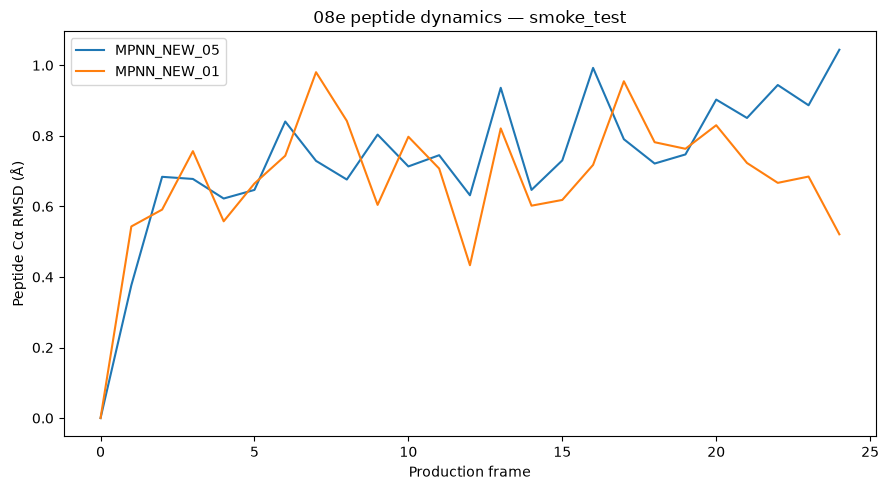

In [37]:
plt.figure(
    figsize=(9, 5)
)

for candidate_id in TARGET_CANDIDATES:

    df = rmsd_df[
        rmsd_df[
            "candidate_id"
        ]
        == candidate_id
    ]

    plt.plot(
        df["frame"],
        df["peptide_CA_RMSD_A"],
        label=candidate_id,
    )

plt.xlabel(
    "Production frame"
)
plt.ylabel(
    "Peptide Cα RMSD (Å)"
)
plt.title(
    f"08e peptide dynamics — {MODE_LABEL}"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "08e_peptide_RMSD.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 25. Contact persistence plot

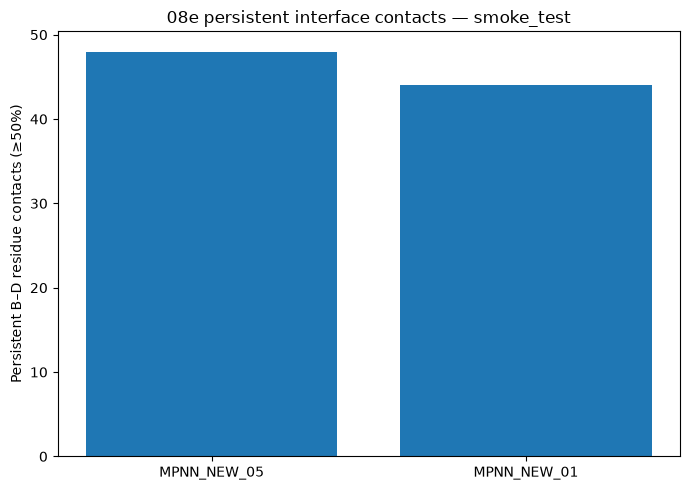

In [38]:
plot_contacts = contact_summary_df.sort_values(
    "n_persistent_contacts_50pct",
    ascending=False,
)

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    plot_contacts[
        "candidate_id"
    ],
    plot_contacts[
        "n_persistent_contacts_50pct"
    ],
)

plt.ylabel(
    "Persistent B–D residue contacts (≥50%)"
)
plt.title(
    f"08e persistent interface contacts — {MODE_LABEL}"
)
plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "08e_persistent_contacts.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 26. QC

In [39]:
qc_rows = [
    {
        "check": "two_targets_loaded",
        "pass": (
            len(input_df) == 2
        ),
    },
    {
        "check": "best_Rosetta_PDBs_present",
        "pass": bool(
            input_df[
                "input_present"
            ].all()
        ),
    },
    {
        "check": "peptide_sequences_match",
        "pass": bool(
            structure_qc_df[
                "peptide_sequence_match"
            ].all()
        ),
    },
    {
        "check": "two_MD_runs_completed",
        "pass": (
            len(run_metadata_df) == 2
        ),
    },
    {
        "check": "temperature_QC",
        "pass": bool(
            thermo_qc_df[
                "temperature_QC"
            ].all()
        ),
    },
    {
        "check": "density_QC",
        "pass": bool(
            thermo_qc_df[
                "density_QC"
            ].all()
        ),
    },
    {
        "check": "trajectory_frames_present",
        "pass": bool(
            (
                trajectory_qc_df[
                    "n_frames"
                ]
                > 0
            ).all()
        ),
    },
    {
        "check": "contact_analysis_complete",
        "pass": (
            len(
                contact_summary_df
            )
            == 2
        ),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(qc_df)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "08e_QC.csv",
    index=False,
)


,check,pass
0,two_targets_loaded,True
1,best_Rosetta_PDBs_present,True
2,peptide_sequences_match,True
3,two_MD_runs_completed,True
4,temperature_QC,True
5,density_QC,True
6,trajectory_frames_present,True
7,contact_analysis_complete,True


ALL QC PASSED: True


## 27. Automatic report

In [40]:
report_lines = [
    "# 08e - Top ProteinMPNN Lead MD Validation",
    "",
    f"- Mode: {MODE_LABEL}",
    f"- Production length per new candidate: {PRODUCTION_PS} ps",
    f"- Target production frames: {N_PRODUCTION_FRAMES}",
    f"- Candidates: {', '.join(TARGET_CANDIDATES)}",
    "",
    "## New ProteinMPNN candidate MD summary",
]

for row in new_md_summary_df.itertuples():

    report_lines.append(
        (
            f"- {row.candidate_id}: "
            f"mean peptide RMSD={row.mean_peptide_CA_RMSD_A:.3f} A; "
            f"mean peptide RMSF={row.mean_peptide_CA_RMSF_A:.3f} A; "
            f"persistent contacts >=50%={int(row.n_persistent_contacts_50pct)}; "
            f"mean contact persistence={row.mean_contact_persistence:.3f}"
        )
    )

if reference_md_df is not None:
    report_lines.extend([
        "",
        "## Established-reference comparison",
        (
            "Existing 07d results for F0010, CF06 and CF02 were imported "
            "rather than rerunning their trajectories."
        ),
    ])
else:
    report_lines.extend([
        "",
        "## Established-reference comparison",
        (
            "The previous 07d summary could not be identified automatically. "
            "New-candidate metrics are still valid, but direct integrated "
            "comparison should be completed once the 07d table is supplied."
        ),
    ])

report_lines.extend([
    "",
    "## Interpretation",
    (
        "08e is a short-timescale explicit-solvent computational validation. "
        "It tests dynamic stability and contact persistence, not experimental "
        "binding affinity."
    ),
    (
        "A ProteinMPNN lead should be advanced only if its favorable static "
        "FoldX/Rosetta evidence remains consistent with acceptable MD behavior."
    ),
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "08e_MD_validation_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(report_text)

print(
    "\nReport:",
    report_path.resolve(),
)


# 08e - Top ProteinMPNN Lead MD Validation

- Mode: smoke_test
- Production length per new candidate: 50.0 ps
- Target production frames: 25
- Candidates: MPNN_NEW_05, MPNN_NEW_01

## New ProteinMPNN candidate MD summary
- MPNN_NEW_01: mean peptide RMSD=0.676 A; mean peptide RMSF=0.515 A; persistent contacts >=50%=44; mean contact persistence=0.757
- MPNN_NEW_05: mean peptide RMSD=0.734 A; mean peptide RMSF=0.538 A; persistent contacts >=50%=48; mean contact persistence=0.707

## Established-reference comparison
Existing 07d results for F0010, CF06 and CF02 were imported rather than rerunning their trajectories.

## Interpretation
08e is a short-timescale explicit-solvent computational validation. It tests dynamic stability and contact persistence, not experimental binding affinity.
A ProteinMPNN lead should be advanced only if its favorable static FoldX/Rosetta evidence remains consistent with acceptable MD behavior.

Report: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_0

# 28. Execution protocol

## First run — smoke test

Keep:

```python
FAST_TEST_MODE = True
```

Run the notebook completely.

The smoke test uses:

```text
10 ps NVT
10 ps NPT
50 ps production
25 frames
```

Its purpose is only to confirm that:

```text
OpenMM setup works
both Rosetta structures are accepted
trajectories are written
MDAnalysis can read them
RMSD/RMSF/contact analysis runs
thermodynamic QC passes
```

Do **not** interpret smoke-test rankings scientifically.

---

## Second run — final production

After:

```text
ALL QC PASSED: True
```

change:

```python
FAST_TEST_MODE = False
```

and rerun from the beginning.

Production uses:

```text
100 ps NVT
100 ps NPT
1 ns production
500 frames
```

matching the scale already used for the established candidates in `07d`.

---

# 29. After production

If one or both ProteinMPNN candidates remain competitive dynamically, the next
logical endpoint step is:

```text
08f — endpoint MM/GBSA-like comparison
```

for only the surviving ProteinMPNN lead(s), using the same type of endpoint
analysis already used in `07e`.

That would complete the ProteinMPNN branch with:

```text
ProteinMPNN
→ ESM-2 integration
→ FoldX
→ Rosetta
→ MD
→ endpoint energetic comparison
```
